In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("./AI_Impact_on_Jobs_2030.csv")

#删除缺失值
df = df.dropna()

#翻译表头
df.rename(columns={"Job_Title":"职业名称"}, inplace=True)
df.rename(columns={"Average_Salary":"平均年薪（美元）"}, inplace=True)
df.rename(columns={"Years_Experience":"平均工作年限"}, inplace=True)
df.rename(columns={"Education_Level":"学历"}, inplace=True)
df.rename(columns={"AI_Exposure_Index":"与AI互动程度"}, inplace=True)
df.rename(columns={"Tech_Growth_Factor":"进步速度"}, inplace=True)
df.rename(columns={"Automation_Probability_2030":"预计在2030年前实现自动化概率"}, inplace=True)
df.rename(columns={"Risk_Category":"自动化风险分类"}, inplace=True)

#数据降维（特征筛选）
df = df[["职业名称","平均年薪（美元）","平均工作年限","学历","与AI互动程度","进步速度","预计在2030年前实现自动化概率","自动化风险分类"]]

df

,职业名称,平均年薪（美元）,平均工作年限,学历,与AI互动程度,进步速度,预计在2030年前实现自动化概率,自动化风险分类
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium
...,...,...,...,...,...,...,...,...
2995,Doctor,111319,6,Bachelor's,0.24,1.18,0.20,Low
2996,UX Researcher,44363,29,PhD,0.65,0.74,0.35,Medium
2997,Data Scientist,61325,23,Master's,0.64,0.94,0.39,Medium
2998,Graphic Designer,110296,7,PhD,0.95,1.23,0.46,Medium


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

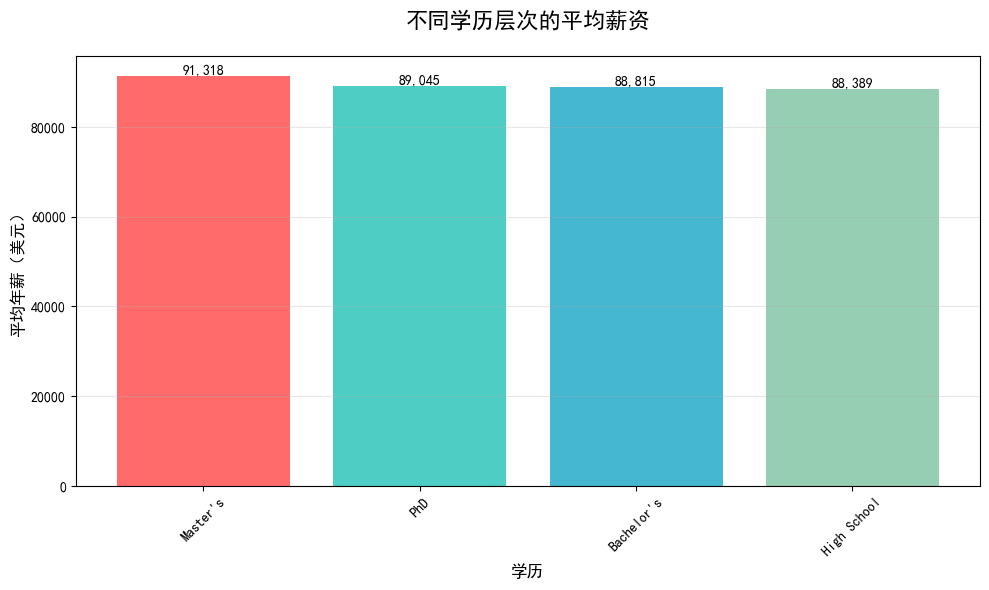

In [5]:
# 1. 柱状图：不同学历层次的平均薪资
plt.figure(figsize=(10, 6))
edu_salary = df.groupby('学历')['平均年薪（美元）'].mean().sort_values(ascending=False)
bars = plt.bar(edu_salary.index, edu_salary.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('不同学历层次的平均薪资', fontsize=16, pad=20)
plt.xlabel('学历', fontsize=12)
plt.ylabel('平均年薪（美元）', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
# 添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(r'./不同学历层次的平均薪资.png')
plt.show()

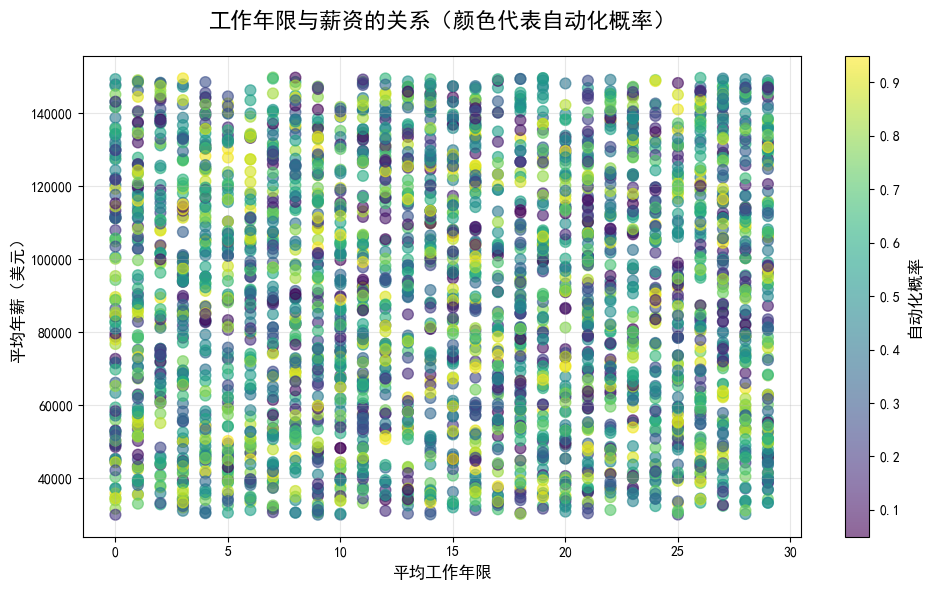

In [6]:
# 2. 散点图：工作年限与薪资的关系
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['平均工作年限'], df['平均年薪（美元）'], 
                     alpha=0.6, c=df['预计在2030年前实现自动化概率'], 
                     cmap='viridis', s=60)
plt.title('工作年限与薪资的关系（颜色代表自动化概率）', fontsize=16, pad=20)
plt.xlabel('平均工作年限', fontsize=12)
plt.ylabel('平均年薪（美元）', fontsize=12)
cbar = plt.colorbar(scatter)
cbar.set_label('自动化概率', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'./工作年限与薪资的关系.png')
plt.show()

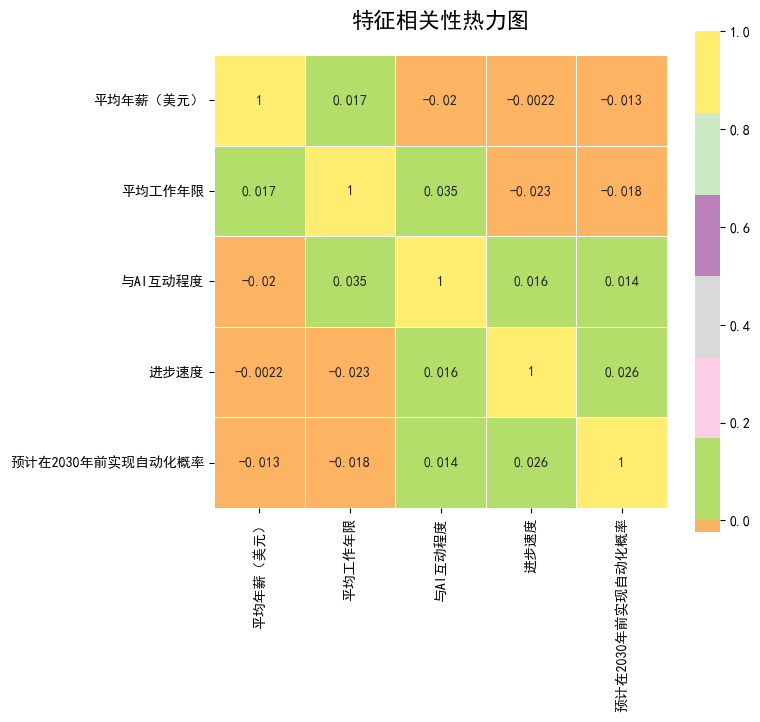

In [7]:
# 3. 热力图：特征相关性矩阵
plt.figure(figsize=(8, 8))
numeric_cols = ['平均年薪（美元）', '平均工作年限', '与AI互动程度', '进步速度', '预计在2030年前实现自动化概率']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Set3', center=0, linewidths=0.5, square=True, cbar_kws={"shrink": .8})
plt.title('特征相关性热力图', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(r'./特征相关性热力图.png')
plt.show()

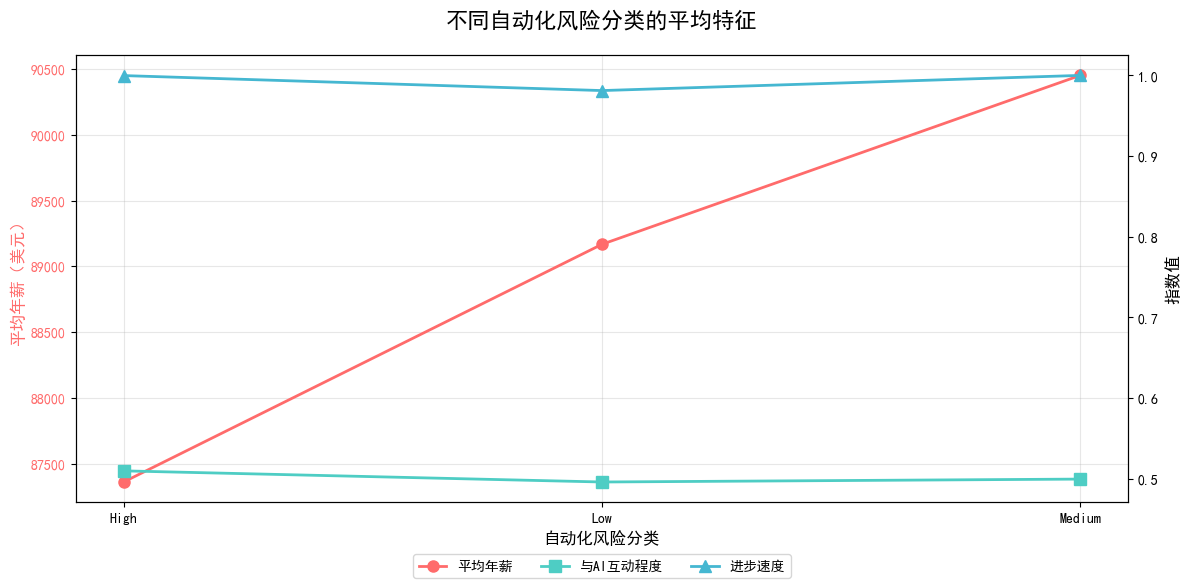

In [8]:
# 4. 折线图：不同自动化风险分类的平均特征
risk_features = df.groupby('自动化风险分类').agg({
    '平均年薪（美元）': 'mean',
    '与AI互动程度': 'mean',
    '进步速度': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

line1 = ax1.plot(risk_features['自动化风险分类'], risk_features['平均年薪（美元）'], 
         marker='o', linewidth=2, markersize=8, label='平均年薪', color='#FF6B6B')
ax1.set_xlabel('自动化风险分类', fontsize=12)
ax1.set_ylabel('平均年薪（美元）', color='#FF6B6B', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#FF6B6B')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
line2 = ax2.plot(risk_features['自动化风险分类'], risk_features['与AI互动程度'], 
         marker='s', color='#4ECDC4', linewidth=2, markersize=8, label='与AI互动程度')
line3 = ax2.plot(risk_features['自动化风险分类'], risk_features['进步速度'], 
         marker='^', color='#45B7D1', linewidth=2, markersize=8, label='进步速度')
ax2.set_ylabel('指数值', color='black', fontsize=12)
ax2.tick_params(axis='y', labelcolor='black')

# 合并图例
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)

plt.title('不同自动化风险分类的平均特征', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(r'./不同自动化风险分类的平均特征.png')
plt.show()

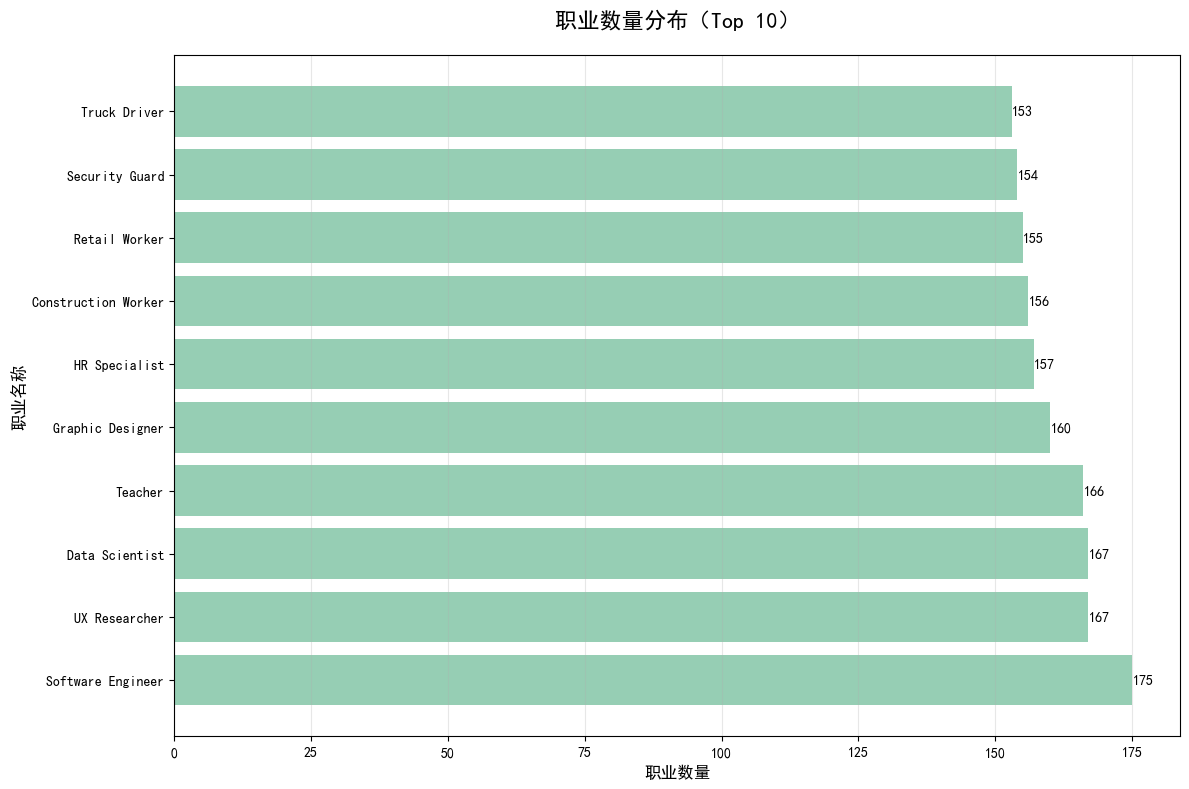

In [9]:
# 5. 水平柱状图：各职业数量分布
plt.figure(figsize=(12, 8))
job_counts = df['职业名称'].value_counts().head(10)
bars = plt.barh(range(len(job_counts)), job_counts.values, color='#96CEB4')
plt.yticks(range(len(job_counts)), job_counts.index)
plt.xlabel('职业数量', fontsize=12)
plt.ylabel('职业名称', fontsize=12)
plt.title('职业数量分布（Top 10）', fontsize=16, pad=20)
plt.grid(axis='x', alpha=0.3)
# 添加数值标签
for i, (bar, count) in enumerate(zip(bars, job_counts.values)):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             str(count), ha='left', va='center')
plt.tight_layout()
plt.savefig(r'./职业数量分布.png')
plt.show()

## 职业预测自动化概率

In [166]:
# 数据预处理：
from sklearn.preprocessing import LabelEncoder

label = {}
columns2 = ['职业名称', '学历', '自动化风险分类']

for col in columns2:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label[col] = le

In [167]:
# 准备特征 X 和目标变量 y 
second_columns = ['职业名称', '平均年薪（美元）', '平均工作年限', '学历', '与AI互动程度', '进步速度']

X = df[second_columns]
y = df['预计在2030年前实现自动化概率']

In [168]:
# 划分训练集和测试集
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [169]:
from sklearn.model_selection import GridSearchCV

In [170]:
# 算法1: 随机森林回归
from sklearn.ensemble import RandomForestRegressor

print("\n1. 随机森林回归模型训练...")
# 参数调优
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rf.fit(X_train, y_train)
best_rf = rf.best_estimator_

print("随机森林最佳参数:", rf.best_params_)
print("随机森林最佳交叉验证得分:", -rf.best_score_)


1. 随机森林回归模型训练...
随机森林最佳参数: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
随机森林最佳交叉验证得分: 0.009653224556744501


In [171]:
# 算法2: 决策树回归
from sklearn.tree import DecisionTreeRegressor

print("\n2. 决策树回归模型训练...")
dt_param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

dt.fit(X_train, y_train)
best_dt = dt.best_estimator_

print("决策树最佳参数:", dt.best_params_)
print("决策树最佳交叉验证得分:", -dt.best_score_)


2. 决策树回归模型训练...
决策树最佳参数: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
决策树最佳交叉验证得分: 0.01168819283580286


In [172]:
# 算法3: K-Means聚类（用于无监督学习分析）
from sklearn.cluster import KMeans

print("\n3. K-Means聚类分析...")
# 为聚类选择相关特征
cluster_features = ['平均年薪（美元）', '平均工作年限', '与AI互动程度', '进步速度']
X_cluster = df[cluster_features]

# 根据肘部法则确定最优聚类数
inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

# 保留3个聚类
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)
df['cluster'] = cluster_labels

print("K-Means聚类完成，轮廓系数:", kmeans.inertia_)


3. K-Means聚类分析...
K-Means聚类完成，轮廓系数: 391825548544.38965


#### 预测特定职业的自动化概率
``` 
    参数:
    Job_Title: 职业名称
    Average_Salary: 平均年薪（美元）
    Years_Experience: 平均工作年限
    Education_Level: 学历
    AI_Exposure_Index: 与AI互动程度 (0-1)
    Tech_Growth_Factor: 技术进步速度 (0-1.5)
    
    返回:
    预测的自动化概率 (0-1)
```

In [173]:
def predict_automation_probability(Job_Title, Average_Salary, Years_Experience, Education_Level, AI_Exposure_Index, Tech_Growth_Factor):
    try:
        # 对输入的分类变量进行编码
        # 如果职业名称不存在于训练数据中，则使用默认值
        if Job_Title in label['职业名称'].classes_:
            Job_Title_encoded = label['职业名称'].transform([Job_Title])[0]
        else:
            # 对于新职业，使用中位数编码
            Job_Title_encoded = len(label['职业名称'].classes_) // 2
            
        # 如果学历不存在于训练数据中，则使用默认值
        if Education_Level in label['学历'].classes_:
            education_encoded = label['学历'].transform([Education_Level])[0]
        else:
            # 对于新学历，使用最常见学历的编码
            education_encoded = 0
            
        # 构造特征向量
        features = np.array([[Job_Title_encoded, Average_Salary, Years_Experience, education_encoded, AI_Exposure_Index, Tech_Growth_Factor]])
        
        # 进行预测
        prediction = best_dt.predict(features)
        
        # 确保预测值在合理范围内
        probability = max(0, min(1, prediction[0]))
        
        return probability
        
    except Exception as e:
        print(f"预测过程中出现错误: {e}")
        return None

In [174]:
# 模型评估及特征重要性
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [175]:
# 随机森林评估
rf_y_pred = best_rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print("\n=== 随机森林回归模型评估 ===")
print(f"均方误差 (MSE): {rf_mse:.4f}")
print(f"平均绝对误差 (MAE): {rf_mae:.4f}")
print(f"决定系数 (R²): {rf_r2:.4f}")

# 随机森林特征重要性
print("\n=== 随机森林特征重要性 ===")
rf_feature_importance = pd.DataFrame({
    '特征': second_columns,
    '重要性': best_rf.feature_importances_
}).sort_values('重要性', ascending=False)
print(rf_feature_importance)


=== 随机森林回归模型评估 ===
均方误差 (MSE): 0.0089
平均绝对误差 (MAE): 0.0785
决定系数 (R²): 0.8610

=== 随机森林特征重要性 ===
         特征       重要性
0      职业名称  0.932024
1  平均年薪（美元）  0.017994
4   与AI互动程度  0.016912
5      进步速度  0.014893
2    平均工作年限  0.012432
3        学历  0.005745


In [176]:
# 决策树评估
dt_y_pred = best_dt.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_y_pred)
dt_mae = mean_absolute_error(y_test, dt_y_pred)
dt_r2 = r2_score(y_test, dt_y_pred)

print("\n=== 决策树回归模型评估 ===")
print(f"均方误差 (MSE): {dt_mse:.4f}")
print(f"平均绝对误差 (MAE): {dt_mae:.4f}")
print(f"决定系数 (R²): {dt_r2:.4f}")

# 决策树特征重要性
print("\n=== 决策树特征重要性 ===")
dt_feature_importance = pd.DataFrame({
    '特征': second_columns,
    '重要性': best_dt.feature_importances_
}).sort_values('重要性', ascending=False)
print(dt_feature_importance)


=== 决策树回归模型评估 ===
均方误差 (MSE): 0.0112
平均绝对误差 (MAE): 0.0850
决定系数 (R²): 0.8244

=== 决策树特征重要性 ===
         特征       重要性
0      职业名称  0.954748
4   与AI互动程度  0.011694
1  平均年薪（美元）  0.011136
5      进步速度  0.009556
2    平均工作年限  0.008965
3        学历  0.003901


In [177]:
# 聚类结果分析
print("\n聚类结果分析: ")
cluster_analysis = df.groupby('cluster')[['平均年薪（美元）', '平均工作年限', '与AI互动程度', '进步速度']].mean()
print(cluster_analysis)


聚类结果分析: 
              平均年薪（美元）     平均工作年限   与AI互动程度      进步速度
cluster                                              
0         89767.643434  14.711111  0.491919  0.981576
1        129476.358794  14.748744  0.498925  1.002503
2         49672.800985  14.575369  0.512729  1.001754


```
算法选择理由
1. 随机森林回归: 适合处理具有多种特征的回归问题，能有效防止过拟合，对异常值不敏感
2. 决策树回归: 简单易解释，能很好地捕捉特征间的非线性关系
3. K-Means聚类: 用于发现数据中的潜在模式，将职业按特征相似性分组
```

In [180]:
# 演示如何使用预测函数
print("\n=== 单个职业自动化概率预测演示 ===")
print("示例1: 预测软件工程师的自动化概率")
software_eng_prob = predict_automation_probability(
    Job_Title="Software Engineer",
    Average_Salary=100000,
    Years_Experience=5,
    Education_Level="Bachelor's",
    AI_Exposure_Index=0.7,
    Tech_Growth_Factor=1.2
)
print(f"软件工程师的自动化概率预测: {software_eng_prob *100:.2f}%")


=== 单个职业自动化概率预测演示 ===
示例1: 预测软件工程师的自动化概率
软件工程师的自动化概率预测: 51.21%


E:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [181]:
print("\n=== 单个职业自动化概率预测演示 ===")
print("示例2: 预测教师的自动化概率")
teacher_prob = predict_automation_probability(
    Job_Title="Teacher",
    Average_Salary=50000,
    Years_Experience=10,
    Education_Level="Bachelor's",
    AI_Exposure_Index=0.4,
    Tech_Growth_Factor=0.8
)
print(f"教师的自动化概率预测: {teacher_prob *100:.2f}%")


=== 单个职业自动化概率预测演示 ===
示例2: 预测教师的自动化概率
教师的自动化概率预测: 48.61%


E:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [182]:
print("=== 交互式预测 ===")
print("输入相关信息预测其自动化概率（输入 'q' 退出）:")

while True:
    try:
        job_title = input("输入职业名称 (或输入 'q' 退出): ")
        if job_title.lower() == 'q':
            break

        average_salary = float(input("输入平均年薪（美元）: "))
        years_experience = float(input("输入平均工作年限: "))
        education_level = input("输入学历: ")
        ai_exposure = float(input("输入与AI互动程度 (0-1): "))
        tech_growth = float(input("输入进步速度 (0-1.5): "))

        probability = predict_automation_probability(job_title, average_salary, years_experience, education_level, ai_exposure, tech_growth)

        if probability is not None:
            print(f"该职业的自动化概率预测:{probability * 100:.2f}%")
        else:
            print("预测失败，请检查输入信息")

        print("-" * 50)

    except ValueError:
        print("输入格式错误，请确保数值字段输入的是数字")
    except KeyboardInterrupt:
        print("程序已退出")
        break
    except Exception as e:
        print(f"发生未知错误: {e}")

=== 交互式预测 ===
输入相关信息预测其自动化概率（输入 'q' 退出）:


输入职业名称 (或输入 'q' 退出):  Chef
输入平均年薪（美元）:  12000
输入平均工作年限:  5
输入学历:  High School
输入与AI互动程度 (0-1):  0.2
输入进步速度 (0-1.5):  0.3


E:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


该职业的自动化概率预测:39.90%
--------------------------------------------------


输入职业名称 (或输入 'q' 退出):  q
